In [3]:
import lerobot
from lerobot.datasets.lerobot_dataset import LeRobotDatasetMetadata
from lerobot.configs.types import NormalizationMode
# from lerobot.constants import ACTION, HF_LEROBOT_HOME, OBS_STATE
from lerobot.datasets.lerobot_dataset import (
    LeRobotDataset as BaseLeRobotDataset,
    LeRobotDatasetMetadata,
    MultiLeRobotDataset as BaseMultiLeRobotDataset,
)
from lerobot.datasets.utils import hf_transform_to_torch, serialize_dict
import lerobot
# print(dir(lerobot))
# from lerobot.policies.normalize import Normalize

from robokit.datasets.eo.lerobot_dataset import LeRobotDataset, MultiLeRobotDataset, LerobotConfig
from robokit.datasets.eo.dataset import InterleavedLeRobotDataset
from robokit.datasets.eo.transforms import ImageTransforms, ImageTransformsConfig
from robokit.datasets.eo.dataset import TrainPipelineConfig

from robokit.debug_utils.printer import print_batch
from robokit.debug_utils.images import save_frames_as_video

from PIL import Image
import numpy as np

2026-01-25 13:04:46.709257: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-25 13:04:46.757422: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-25 13:04:46.757477: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-25 13:04:46.758732: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-25 13:04:46.767033: I tensorflow/core/platform/cpu_feature_guar

In [2]:
lerobot_dataset = MultiLeRobotDataset(
    data_configs=[
        # LerobotConfig(
        #     repo_id="fractal20220817_data_lerobot",
        #     root="/home/geyuan/datasets/ipec_lerobot/",
        #     episodes=[0],
        #     select_video_keys=["observation.images.image"],
        #     load_future_frames=True,
        #     future_skip_frames=1,
        # ),
        # LerobotConfig(
        #     repo_id="bridge_orig_lerobot",
        #     root="/home/geyuan/datasets/ipec_lerobot/",
        #     episodes=[5],
        #     select_video_keys=["observation.images.image_0"],
        #     load_future_frames=True,
        #     future_skip_frames=1,
        # ),
        # LerobotConfig(
        #     repo_id="viola_lerobot",
        #     root="/home/geyuan/datasets/ipec_lerobot/fork",
        #     episodes=[5],
        #     select_video_keys=["observation.images.agentview_rgb"],
        #     load_future_frames=False,
        #     future_skip_frames=1,
        # ),
        LerobotConfig(
            repo_id="droid_lerobot",
            root="/home/geyuan/datasets/ipec_lerobot/",
            episodes=[5],
            select_video_keys=["observation.images.exterior_image_2_left"],
            load_future_frames=False,
            future_skip_frames=1,
        ),
    ],
    chunk_size=12, # automatically construct delta_timestamps from the `metadata` and `chunk_size`
    image_transforms=ImageTransforms(ImageTransformsConfig()),
)

print(lerobot_dataset.image_transforms)
# print(lerobot_dataset._datasets)
# print(lerobot_dataset[0].keys())
# print(lerobot_dataset[140].keys())

NameError: name 'MultiLeRobotDataset' is not defined

In [4]:
print(len(lerobot_dataset))

print_batch("lerobot_dataset", lerobot_dataset[136])

140
lerobot_dataset: Dict, keys=['observation.images.image_0', 'observation.state', 'action', 'task', 'action_is_pad']
--observation.images.image_0, <class 'torch.Tensor'>, shape=torch.Size([13, 3, 250, 251]), min=0.0000, max=1.0000, dtype=torch.float32
--observation.state, <class 'torch.Tensor'>, shape=torch.Size([8]), min=-1.0304, max=1.6191, dtype=torch.float32
--action, <class 'torch.Tensor'>, shape=torch.Size([12, 7]), min=-1.5546, max=0.8569, dtype=torch.float32
--task: <class 'str'>, len=24, value='take broccoli out of pan'
--action_is_pad, <class 'torch.Tensor'>, shape=torch.Size([12]), min=0.0000, max=1.0000, dtype=torch.bool


In [5]:
# T, C, H, W = lerobot_dataset[130]["observation.images.image_0"].shape
# print(T, C, H, W)
# frames = [lerobot_dataset[130]["observation.images.image_0"][t].permute(1, 2, 0).numpy() for t in range(T)]  # each frame is HWC
# save_frames_as_video(
#     frames=frames,
#     save_path="./de_eo_lerobot_dataset_images.mp4",
#     fps=5,
# )

single_img = lerobot_dataset[130]["observation.images.image_0"]
T, C, H, W = single_img.shape
from robokit.datasets.eo.transforms import RandomScaleCrop, v2
transform1 = RandomScaleCrop(scale=(0.8, 1.0),)
transform2 = v2.RandomRotation(degrees=(-15, 15))
transform3 = v2.ColorJitter(
    brightness=(0.8, 1.2),
    contrast=(0.8, 1.2),
    saturation=(0.5, 1.5),
    hue=(-0.05, 0.05),
)
transform = v2.Compose([
    transform1,
    transform2,
    transform3,
])
transformed_img = transform(single_img)

frames_ori = [single_img[t].permute(1, 2, 0).numpy() for t in range(T)]  # each frame is HWC
save_frames_as_video(
    frames=frames_ori,
    save_path="./de_eo_lerobot_dataset_images_original.mp4",
    fps=5,
)
frames_crop = [transformed_img[t].permute(1, 2, 0).numpy() for t in range(T)]  # each frame is HWC
save_frames_as_video(
    frames=frames_crop,
    save_path="./de_eo_lerobot_dataset_images_cropped.mp4",
    fps=5,
)

# image = np.concatenate([lerobot_dataset[130][k][3].permute(1, 2, 0).numpy() for \
#     k in ['observation.images.image_0']], axis=1) * 255
# Image.fromarray(image.astype(np.uint8))

'./de_eo_lerobot_dataset_images_cropped.mp4'

In [3]:
# from lerobot.constants import ACTION, OBS_IMAGE, OBS_STATE
# print(ACTION)
# print(OBS_IMAGE)
# print(OBS_STATE)

data_config = TrainPipelineConfig(
    data_path="./de_eo_oxe.yaml",
    chunk_size=2,
    image_resized_width=176,
    image_resized_height=176,
)
interleaved_dataset = InterleavedLeRobotDataset(
    args=data_config,
)

NameError: name 'TrainPipelineConfig' is not defined

In [34]:
print_batch("interleaved_dataset", interleaved_dataset[10])

lerobot_dataset = interleaved_dataset.lerobot_dataset
print_batch("x", lerobot_dataset[120])
print_batch("x", lerobot_dataset[10])

from robokit.debug_utils.images import save_frames_as_video
B, T, C, H, W = interleaved_dataset[0]["images"].shape
frames = [interleaved_dataset[0]["images"][0, t].permute(1, 2, 0).numpy() for t in range(T)]  # each frame is HWC
save_frames_as_video(
    frames=frames,
    save_path="./de_eo_interleaved_dataset_images.mp4",
    fps=5,
)

image = np.concatenate([lerobot_dataset[10][k][12].permute(1, 2, 0).numpy() for \
    k in ['observation.images.image_0']], axis=1) * 255
Image.fromarray(image.astype(np.uint8))

interleaved_dataset: Dict, keys=['images', 'actions', 'states', 'action_is_pad', 'task']
--images, <class 'torch.Tensor'>, shape=torch.Size([1, 3, 3, 176, 176]), min=0.0154, max=0.9081, dtype=torch.float32
--actions, <class 'torch.Tensor'>, shape=torch.Size([1, 2, 32]), min=-3.2643, max=1.0232, dtype=torch.float32
--states, <class 'torch.Tensor'>, shape=torch.Size([1, 32]), min=-1.3993, max=0.9018, dtype=torch.float32
--action_is_pad, <class 'torch.Tensor'>, shape=torch.Size([1, 2]), min=0.0000, max=0.0000, dtype=torch.bool
--task: <class 'str'>, len=16, value='assemble one_leg'
x: Dict, keys=['observation.images.image', 'observation.state', 'action', 'task', 'action_is_pad']
--observation.images.image, <class 'torch.Tensor'>, shape=torch.Size([3, 3, 223, 223]), min=0.0000, max=0.8982, dtype=torch.float32
--observation.state, <class 'torch.Tensor'>, shape=torch.Size([8]), min=-1.9004, max=1.6618, dtype=torch.float32
--action, <class 'torch.Tensor'>, shape=torch.Size([2, 7]), min=-0.072

NameError: name 'np' is not defined

In [ ]:
print_batch("interleaved_dataset", interleaved_dataset[10])

lerobot_dataset = interleaved_dataset.lerobot_dataset
print_batch("x", lerobot_dataset[120])
print_batch("x", lerobot_dataset[10])

from robokit.debug_utils.images import save_frames_as_video
T, C, H, W = interleaved_dataset[0]["images"].shape
frames = [interleaved_dataset[0]["images"][t].permute(1, 2, 0).numpy() for t in range(T)]  # each frame is HWC
save_frames_as_video(
    frames=frames,
    save_path="./de_eo_interleaved_dataset_images.mp4",
    fps=5,
)

image = np.concatenate([lerobot_dataset[10][k][12].permute(1, 2, 0).numpy() for \
    k in ['observation.images.image']], axis=1) * 255
Image.fromarray(image.astype(np.uint8))

torch.Size([16, 7])


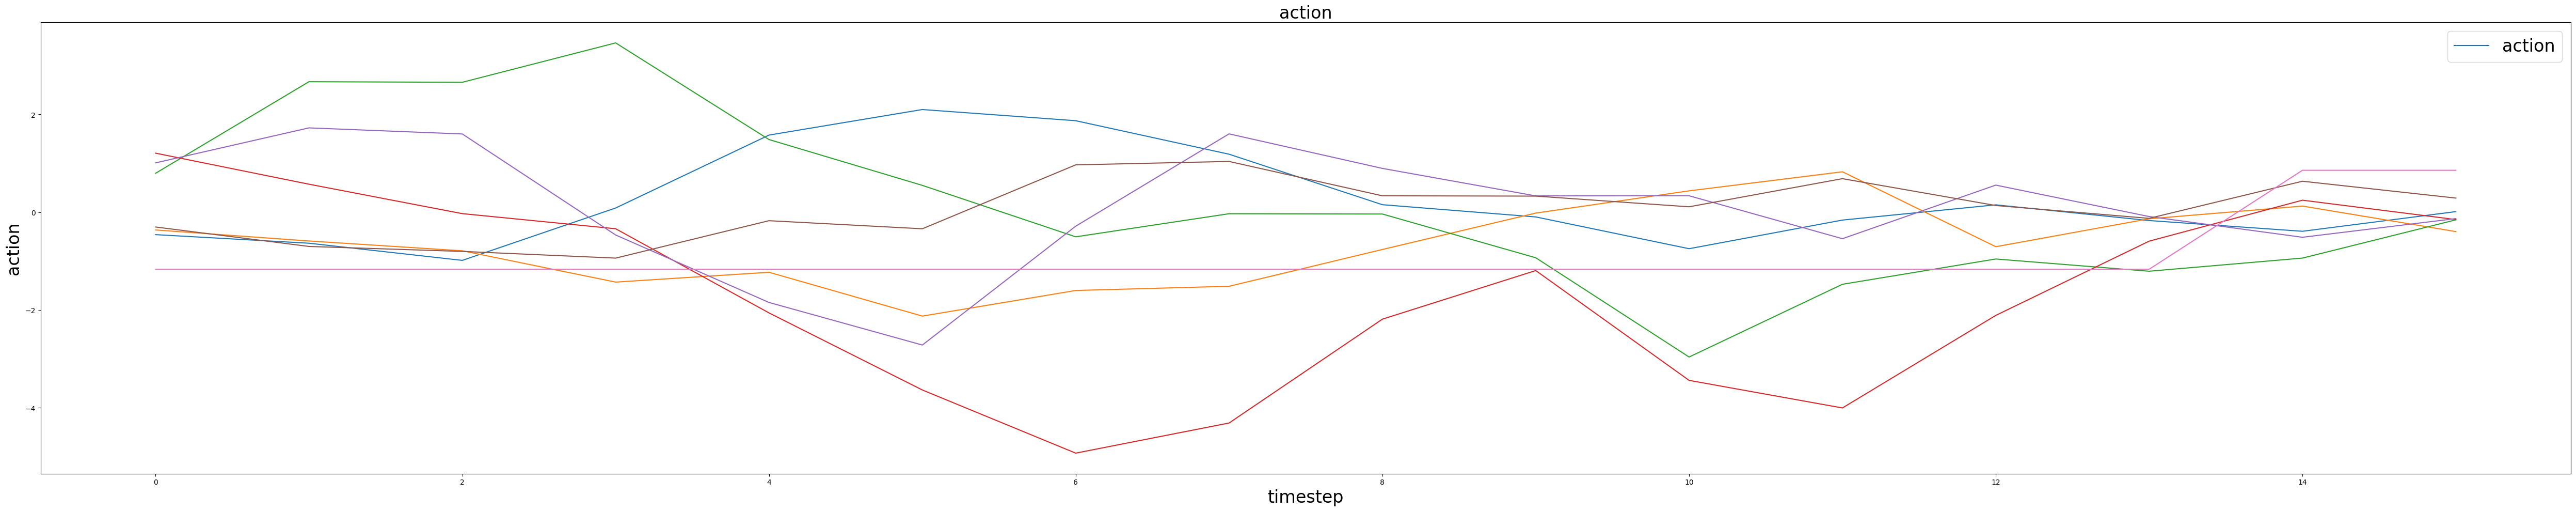

In [25]:
import matplotlib.pyplot as plt

select_action_keys = ['action']
fig, axs = plt.subplots(1, len(select_action_keys), figsize=(50, 10))
axs = [axs]

item = lerobot_dataset[10]
for k, ax in zip(select_action_keys, axs):
    actions = item[k][::1]
    print(actions.shape)
    for i in range(actions.shape[1]):
        ax.plot(actions[:, i])
    ax.legend([k], fontsize=24)
    ax.set_xlabel("timestep", fontsize=24)
    ax.set_ylabel("action", fontsize=24)
    ax.set_title(k, fontsize=24)
plt.tight_layout()

In [52]:
import torch.utils.data.dataloader

print(len(interleaved_dataset))
dataloader = torch.utils.data.DataLoader(
    interleaved_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=4,
    drop_last=True,
)

5679426


batch: Dict, keys=['images', 'actions', 'states', 'action_is_pad', 'task']
--images, <class 'torch.Tensor'>, shape=torch.Size([4, 1, 3, 176, 176]), min=0.0000, max=0.9781, dtype=torch.float32
--actions, <class 'torch.Tensor'>, shape=torch.Size([4, 1, 16, 32]), min=-6.1786, max=2.5686, dtype=torch.float32
--states, <class 'torch.Tensor'>, shape=torch.Size([4, 1, 32]), min=-2.2662, max=5.1690, dtype=torch.float32
--action_is_pad, <class 'torch.Tensor'>, shape=torch.Size([4, 1, 16]), min=0.0000, max=1.0000, dtype=torch.bool
--task: List, len=4, elem_type=<class 'str'>
----[0]: <class 'str'>, len=41, value='move the bowl to upper left edge of table'
tensor([[ 0.2482,  1.2574, -0.7837,  5.1690,  0.6076, -0.6325,  0.0000, -1.2363],
        [ 0.4106,  0.9393,  0.3474,  2.1021, -1.8634,  0.1900, -1.6858, -0.9390],
        [ 0.1562, -0.9721, -2.2662,  1.7757, -2.2060, -1.8997, -1.7724,  0.2631],
        [-0.4169,  0.1125,  0.1134, -0.4421,  0.5373,  1.0913,  0.3658,  1.2642]])
torch.Size([4, 1,

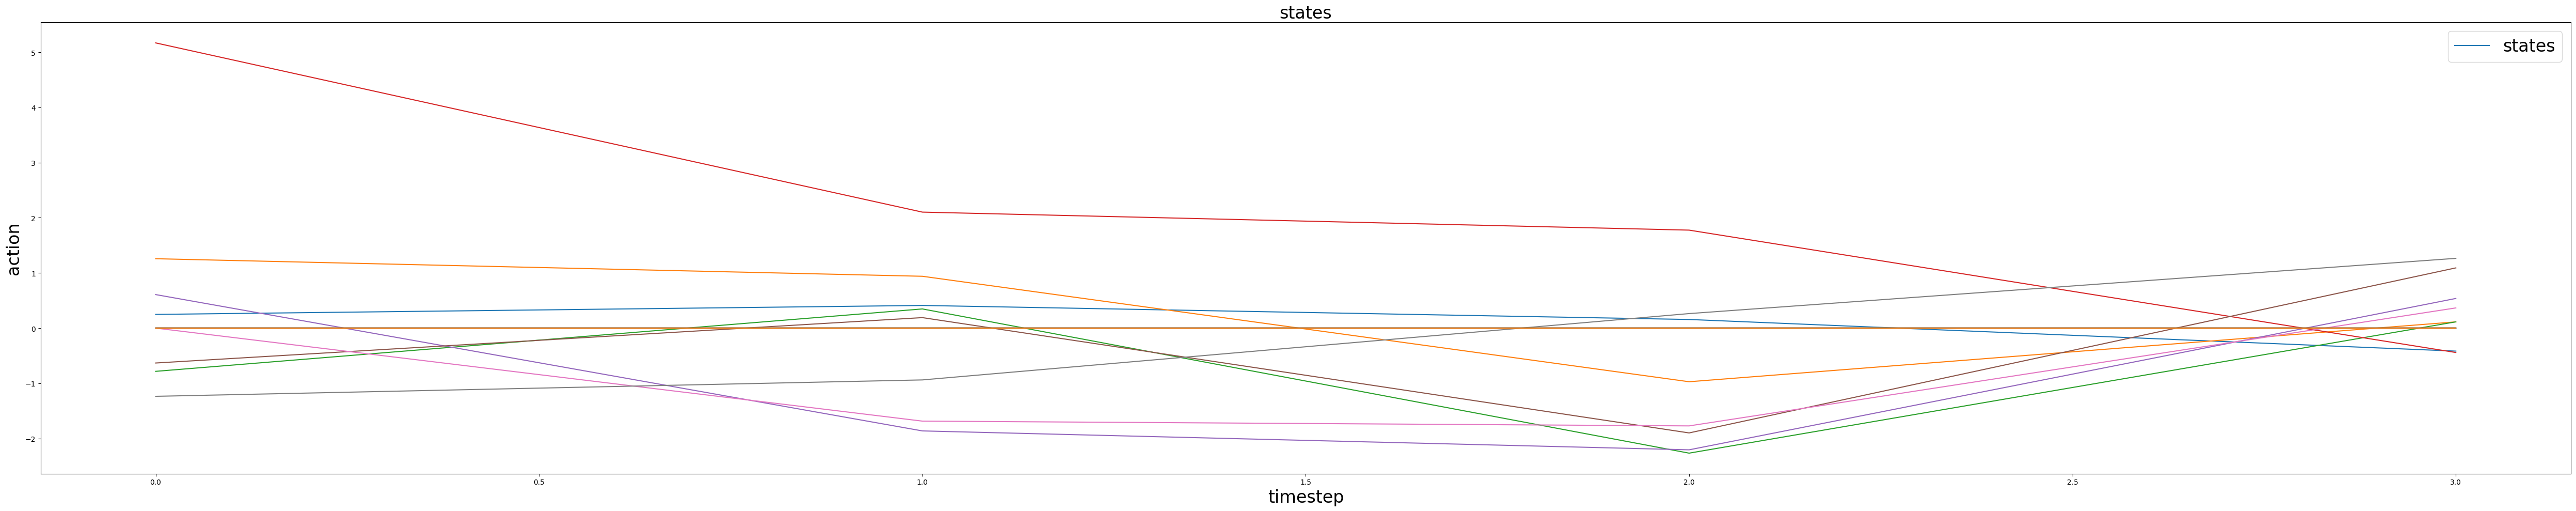

In [28]:
batch = next(iter(dataloader))
print_batch("batch", batch)

print("===" * 10)
print(batch["states"][:, 0, :8])

select_action_keys = ['states']
fig, axs = plt.subplots(1, len(select_action_keys), figsize=(50, 10))
axs = [axs]
for k, ax in zip(select_action_keys, axs):
    actions = batch[k][::1]
    print(actions.shape)
    for i in range(actions.shape[1]):
        ax.plot(actions[:, i])
    ax.legend([k], fontsize=24)
    ax.set_xlabel("timestep", fontsize=24)
    ax.set_ylabel("action", fontsize=24)
    ax.set_title(k, fontsize=24)
plt.tight_layout()

In [51]:
print(dir(interleaved_dataset.lerobot_dataset))
print(interleaved_dataset.lerobot_dataset.repo_id_to_index)
print(interleaved_dataset.lerobot_dataset._datasets[0].normalizer.stats)

['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_datasets', '_features', '_is_protocol', '_repo_ids_index', '_select_action_keys', '_select_state_keys', '_select_video_keys', '_stats', 'camera_keys', 'chunk_size', 'configuration', 'cumulative_sizes', 'data_configs', 'disabled_features', 'features', 'fps', 'getitem_by_id', 'image_transforms', 'num_episodes', 'num_frames', 'post_process', 'repo_id_to_index', 'repo_ids', 'repo_index_to_id', 'state_mode', 'tolerance_s', 'video', 'video_frame_keys']
{'bridge_orig_lerobot': 0, 'fractal20220817_data_lerobot': 1}
{'observation.

In [9]:
import os
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader
import lerobot
from robokit.datasets.eo.lerobot_dataset import LerobotConfig, LeRobotDataset, LeRobotDatasetMetadata, MultiLeRobotDataset
from robokit.datasets.eo.dataset import InterleavedLeRobotDataset, TrainPipelineConfig
from robokit.datasets.eo.transforms import ImageTransforms, ImageTransformsConfig

from robokit.debug_utils.printer import print_batch

print("All modules imported.")

""" DEBUG: LeRobotDataset """
repo_id="droid_lerobot"
root="/home/geyuan/datasets/ipec_lerobot/"
meta = LeRobotDatasetMetadata(repo_id, root=os.path.join(root, repo_id))
print("meta:", meta)
print("***" * 10)
lerobot_dataset = LeRobotDataset(
    repo_id=repo_id,
    root=os.path.join(root, repo_id),
    episodes=[5],
    select_video_keys=["observation.images.exterior_image_2_left"],
    # select_action_keys=["action.cartesian_position", "action.gripper_position"],
    load_future_frames=False,
    future_skip_frames=1,
)
print(f"lerobot_dataset len={len(lerobot_dataset)}")
print("action_keys:", lerobot_dataset.select_action_keys)
print_batch("lerobot_dataset", lerobot_dataset[0])
print("***" * 10)

""" DEBUG: MultiLeRobotDataset """
multilerobot_dataset = MultiLeRobotDataset(
    data_configs=[
        # LerobotConfig(
        #     repo_id="fractal20220817_data_lerobot",
        #     root="/home/geyuan/datasets/ipec_lerobot/",
        #     episodes=[0],
        #     select_video_keys=["observation.images.image"],
        #     load_future_frames=True,
        #     future_skip_frames=1,
        # ),
        # LerobotConfig(
        #     repo_id="bridge_orig_lerobot",
        #     root="/home/geyuan/datasets/ipec_lerobot/",
        #     episodes=[33337],
        #     select_video_keys=["observation.images.image_0"],
        #     load_future_frames=True,
        #     future_skip_frames=1,
        # ),
        LerobotConfig(
            repo_id="droid_lerobot",
            root="/home/geyuan/datasets/ipec_lerobot/",
            episodes=[5],
            select_video_keys=["observation.images.exterior_image_2_left"],
            load_future_frames=False,
            future_skip_frames=1,
        ),
        # LerobotConfig(
        #     repo_id="droid_1.0.1",
        #     root="/home/geyuan/datasets/ipec_lerobot/fork/",
        #     episodes=[37],
        #     select_video_keys=["observation.images.exterior_1_left"],
        #     select_state_keys=["observation.state"],
        #     select_action_keys=["action.cartesian_position"],
        #     load_future_frames=True,
        #     future_skip_frames=1,
        # ),
        # LerobotConfig(
        #     repo_id="viola_lerobot",
        #     root="/home/geyuan/datasets/ipec_lerobot/fork",
        #     # episodes=[5],
        #     select_video_keys=["observation.images.agentview_rgb"],
        #     load_future_frames=True,
        #     future_skip_frames=1,
        # ),
        # LerobotConfig(
        #     repo_id="cmu_stretch_lerobot",
        #     root="/home/geyuan/datasets/ipec_lerobot/fork",
        #     select_video_keys=["observation.images.image"],
        #     load_future_frames=True,
        #     future_skip_frames=1,
        # ),
        # LerobotConfig(
        #     repo_id="bc_z_lerobot",
        #     root="/home/geyuan/datasets/ipec_lerobot/fork",
        #     select_video_keys=["observation.images.image"],
        #     load_future_frames=True,
        #     future_skip_frames=1,
        # ),
    ],
    chunk_size=12,  # automatically construct delta_timestamps
    image_transforms=ImageTransforms(ImageTransformsConfig()),
)
print(f"multilerobot_dataset len={len(multilerobot_dataset)}")
print_batch("multilerobot_dataset", multilerobot_dataset[0])
print("***" * 10)

""" DEBUG: InterleavedLeRobotDataset """
interleaved_dataset = InterleavedLeRobotDataset(
    args=TrainPipelineConfig(
        data_path="/home/geyuan/code/github/RoboKit/debug/data/de_eo_oxe.yaml",
        chunk_size=128,
        image_resized_width=176,
        image_resized_height=176,
        load_future_frames=True,
        future_skip_frames=1,
    ),
)
print(f"interleaved_dataset len={len(interleaved_dataset)}")
print_batch("interleaved_dataset", interleaved_dataset[0])
print("***" * 10)

""" DEBUG: DataLoader for InterleavedLeRobotDataset """
dataloader = DataLoader(
    interleaved_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=12,
    drop_last=False,
)
print(f"Dataloader len={len(dataloader)}")
batch = next(iter(dataloader))
print_batch("dataloader batch", batch)
print("***" * 10)

# for idx, batch in enumerate(tqdm(dataloader, desc="Iterating dataloader")):
#     pass
# print("Debugging complete.")

All modules imported.
meta: LeRobotDatasetMetadata({
    Repository ID: 'droid_lerobot',
    Total episodes: '92233',
    Total frames: '27044326',
    Features: '['observation.images.exterior_image_1_left', 'observation.images.exterior_image_2_left', 'observation.images.wrist_image_left', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})',

******************************
[DEBUG] repo_id=droid_lerobot, root=/home/geyuan/datasets/ipec_lerobot/droid_lerobot
lerobot_dataset len=150
action_keys: ['action']
lerobot_dataset: Dict, keys=['observation.images.exterior_image_2_left', 'observation.state', 'action', 'task', 'action_is_pad']
--observation.images.exterior_image_2_left, <class 'torch.Tensor'>, shape=torch.Size([3, 180, 320]), min=0.0000, max=0.9843, dtype=torch.float32
--observation.state, <class 'torch.Tensor'>, shape=torch.Size([8]), min=-1.7669, max=1.5159, dtype=torch.float32
--action, <class 'torch.Tensor'>, shape=torch.Size(

Loading lerobot datasets:   0%|                                                                                  | 0/1 [00:00<?, ?it/s]

[DEBUG] repo_id=droid_lerobot, root=/home/geyuan/datasets/ipec_lerobot/droid_lerobot
[warn] droid_lerobot failed to calculate episode subtask cumulate: 'Dataset' object has no attribute 'items'
* set train_subtask None for droid_lerobot


Loading lerobot datasets: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.72it/s]


successfully load dataset 1/1:
['droid_lerobot'] 
multilerobot_dataset len=150
multilerobot_dataset: Dict, keys=['observation.images.exterior_image_2_left', 'observation.state', 'action', 'task', 'action_is_pad']
--observation.images.exterior_image_2_left, <class 'torch.Tensor'>, shape=torch.Size([3, 180, 320]), min=0.0000, max=0.9843, dtype=torch.float32
--observation.state, <class 'torch.Tensor'>, shape=torch.Size([8]), min=-1.7669, max=1.5159, dtype=torch.float32
--action, <class 'torch.Tensor'>, shape=torch.Size([12, 7]), min=-0.1050, max=0.9076, dtype=torch.float32
--task: <class 'str'>, len=0, value=''
--action_is_pad, <class 'torch.Tensor'>, shape=torch.Size([12]), min=1.0000, max=1.0000, dtype=torch.bool
******************************
* load 3 lerobot datasets with 3 processes ...


...

[DEBUG] repo_id=fractal20220817_data_lerobot, root=/home/geyuan/datasets/ipec_lerobot/fractal20220817_data_lerobot
[DEBUG] repo_id=droid_lerobot, root=/home/geyuan/datasets/ipec_lerobot/droid_lerobot
[DEBUG] repo_id=bridge_orig_lerobot, root=/home/geyuan/datasets/ipec_lerobot/bridge_orig_lerobot
[warn] fractal20220817_data_lerobot failed to calculate episode subtask cumulate: 'Dataset' object has no attribute 'items'
* set train_subtask None for fractal20220817_data_lerobot
[warn] bridge_orig_lerobot failed to calculate episode subtask cumulate: 'Dataset' object has no attribute 'items'
* set train_subtask None for bridge_orig_lerobot


Loading lerobot datasets:  33%|████████████████████████▋                                                 | 1/3 [00:34<01:08, 34.50s/it]

[warn] droid_lerobot failed to calculate episode subtask cumulate: 'Dataset' object has no attribute 'items'
* set train_subtask None for droid_lerobot


Loading lerobot datasets: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:42<00:00, 14.04s/it]


successfully load dataset 3/3:
['bridge_orig_lerobot', 'fractal20220817_data_lerobot', 'droid_lerobot'] 
interleaved_dataset len=32723752
interleaved_dataset: Dict, keys=['images', 'actions', 'states', 'action_is_pad', 'task']
--images, <class 'torch.Tensor'>, shape=torch.Size([1, 129, 3, 176, 176]), min=0.0831, max=0.9119, dtype=torch.float32
--actions, <class 'torch.Tensor'>, shape=torch.Size([1, 128, 32]), min=-4.9280, max=3.4621, dtype=torch.float32
--states, <class 'torch.Tensor'>, shape=torch.Size([1, 32]), min=-0.3275, max=3.1667, dtype=torch.float32
--action_is_pad, <class 'torch.Tensor'>, shape=torch.Size([1, 128]), min=0.0000, max=1.0000, dtype=torch.bool
--task: <class 'str'>, len=35, value='put small spoon from basket to tray'
******************************
Dataloader len=4090469
dataloader batch: Dict, keys=['images', 'actions', 'states', 'action_is_pad', 'task']
--images, <class 'torch.Tensor'>, shape=torch.Size([8, 1, 129, 3, 176, 176]), min=0.0000, max=1.0000, dtype=tor

In [18]:
one_dataset_meta = interleaved_dataset.lerobot_dataset._datasets[0].meta
print(dir(one_dataset_meta))
print(one_dataset_meta.repo_id)
one_dataset_tasks_pd_frame = one_dataset_meta.tasks
pd_len = len(one_dataset_tasks_pd_frame)
# for task_text, task_idx in tqdm(one_dataset_tasks_pd_frame["task_index"].items(), total=pd_len):
#     print(task_idx, task_text)

['__class__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_close_writer', '_flush_metadata_buffer', '_save_episode_metadata', '_version', 'camera_keys', 'chunks_size', 'create', 'data_files_size_in_mb', 'data_path', 'episodes', 'features', 'fps', 'get_chunk_settings', 'get_data_file_path', 'get_task_index', 'get_video_file_path', 'image_keys', 'info', 'latest_episode', 'load_metadata', 'metadata_buffer', 'metadata_buffer_size', 'names', 'pull_from_repo', 'repo_id', 'revision', 'robot_type', 'root', 'save_episode', 'save_episode_tasks', 'shapes', 'stats', 'tasks', 'total_episodes', 'total_frames', 'total_tasks', 'update_chunk_settings', 'update_video_info', 'url_root', 'video_files_size_in_mb'

Visualize InterleavedLeRobotDataset

Take the blocks in the bowl and put them on the table
torch.Size([128, 8])


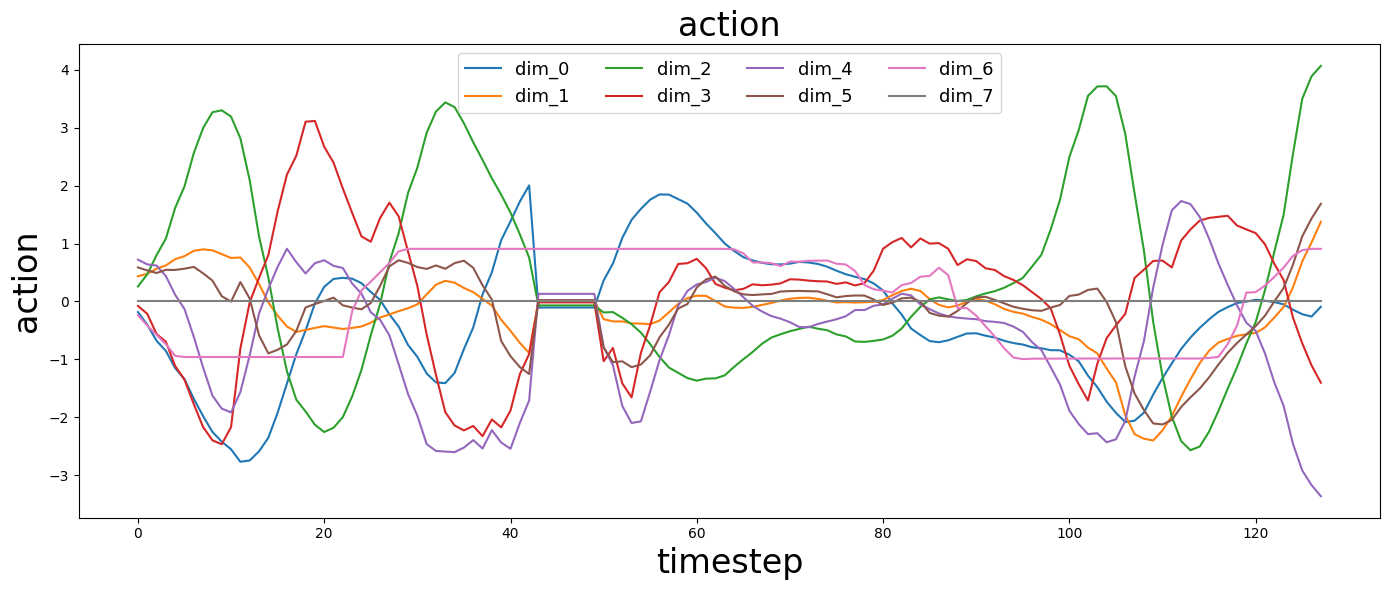

In [8]:
""" Visualize: Images """
from robokit.debug_utils.images import save_frames_as_video
vis_item = interleaved_dataset[10001]
vis_images = vis_item["images"]
B, T, C, H, W = vis_images.shape
frames = [vis_images[0, t].permute(1, 2, 0).numpy() for t in range(T)]  # each frame is HWC
save_frames_as_video(
    frames=frames,
    save_path=f"./de_eo_interleaved_{vis_item['task'][:50]}.mp4",
    fps=5,
)
print(vis_item["task"])

""" Visualize: Actions """
import matplotlib.pyplot as plt

select_action_keys = ['action']
fig, axs = plt.subplots(1, len(select_action_keys), figsize=(14, 6))
axs = [axs]

vis_action = vis_item["actions"][0, :, :8]  # (B,T,action_dim)->(T,action_dim)
for k, ax in zip(select_action_keys, axs):
    actions = vis_action[::1]  # shape (T, action_dim)
    print(actions.shape)
    for i in range(actions.shape[1]):
        ax.plot(actions[:, i], label=f"dim_{i}")
    ax.legend(fontsize=13, ncol=4)
    ax.set_xlabel("timestep", fontsize=24)
    ax.set_ylabel("action", fontsize=24)
    ax.set_title(k, fontsize=24)
plt.tight_layout()

Visualize MultiLeRobotDataset

In [9]:
""" Visualize: Images """
from robokit.debug_utils.images import save_frames_as_video
vis_item = multilerobot_dataset[0]
vis_images = vis_item["observation.images.exterior_1_left"]
T, C, H, W = vis_images.shape
frames = [vis_images[t].permute(1, 2, 0).numpy() for t in range(T)]  # each frame is HWC
save_frames_as_video(
    frames=frames,
    save_path=f"./de_eo_multilerobot_{vis_item['task'][:50]}.mp4",
    fps=5,
)
print(vis_item["task"])

""" Visualize: Actions """
import matplotlib.pyplot as plt

select_action_keys = ['action']
fig, axs = plt.subplots(1, len(select_action_keys), figsize=(14, 6))
axs = [axs]

vis_action = vis_item["action"]
for k, ax in zip(select_action_keys, axs):
    actions = vis_action[::1]  # shape (T, action_dim)
    print(actions.shape)
    for i in range(actions.shape[1]):
        ax.plot(actions[:, i], label=f"dim_{i}")
    ax.legend(fontsize=13, ncol=4)
    ax.set_xlabel("timestep", fontsize=24)
    ax.set_ylabel("action", fontsize=24)
    ax.set_title(k, fontsize=24)
plt.tight_layout()

KeyError: 'observation.images.exterior_1_left'